# 01.01 · El Perceptrón de Rosenblatt (1958)

**Objetivo:** Comprender el primer modelo matemático de una neurona artificial propuesto por Frank Rosenblatt en 1958, implementar su regla de aprendizaje desde cero usando NumPy y PyTorch, y explorar de forma práctica **sus limitaciones fundamentales** (demostradas por Minsky y Papert en 1969).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USUARIO/REPO/blob/main/labs/dl-lab/notebooks/01-fundamentos/01-que-es-y-de-donde-viene/01_01_perceptron_rosenblatt_1958.ipynb)

In [1]:
# --- Bootstrap: local o Colab ---------------------------------------------
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/TU_USUARIO/dl-lab.git"

if IN_COLAB:
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/dl-lab"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/dl-lab"], check=True)
    sys.path.insert(0, "/content/dl-lab/src")

print("Ejecutando en:", "Google Colab" if IN_COLAB else "Local (Docker)")

Ejecutando en: Local (Docker)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import fetch_openml, make_blobs
from sklearn.model_selection import train_test_split

from dllab import describe_device, get_device, set_seed

set_seed(42)
device = get_device()
print(describe_device(device))

torch 2.13.0+cpu | device: cpu


## 1. La Matemática del Perceptrón

Para una entrada $x \in \mathbb{R}^d$, un vector de pesos $w \in \mathbb{R}^d$ y un sesgo (bias) $b \in \mathbb{R}$:

$$ z = w^T x + b = \sum_{i=1}^{d} w_i x_i + b $$

La función de activación es una **función escalón (Heaviside)**:

$$ \hat{y} = f(z) = \begin{cases} 1 & \text{si } z \ge 0 \\ 0 & \text{si } z < 0 \end{cases} $$

### Regla de actualización de Rosenblatt:
Para cada muestra $(x^{(i)}, y^{(i)})$, la actualización de pesos se realiza mediante:

$$ w \leftarrow w + \eta (y^{(i)} - \hat{y}^{(i)}) x^{(i)} $$
$$ b \leftarrow b + \eta (y^{(i)} - \hat{y}^{(i)}) $$

donde $\eta \in (0, 1]$ es la tasa de aprendizaje (*learning rate*).

## 2. Implementación desde cero en NumPy

In [3]:
class PerceptronNumPy:
    def __init__(self, in_features: int, lr: float = 0.1, max_epochs: int = 100):
        self.lr = lr
        self.max_epochs = max_epochs
        self.weights = np.zeros(in_features)
        self.bias = 0.0
        self.errors_history = []

    def predict(self, X: np.ndarray) -> np.ndarray:
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0.0, 1, 0)

    def fit(self, X: np.ndarray, y: np.ndarray):
        n_samples, _ = X.shape
        self.weights = np.zeros(X.shape[1])
        self.bias = 0.0

        for epoch in range(self.max_epochs):
            errors = 0
            for xi, target in zip(X, y):
                y_pred = self.predict(xi.reshape(1, -1))[0]
                update = self.lr * (target - y_pred)
                if update != 0.0:
                    self.weights += update * xi
                    self.bias += update
                    errors += 1
            self.errors_history.append(errors)
            if errors == 0:
                print(f"Convergió en la época {epoch + 1}!")
                break
        return self

## 3. Puertas Lógicas Básicas: AND, OR y el dilema XOR

Comprobaremos el Teorema de Convergencia del Perceptrón: si las dos clases son **linealmente separables**, el algoritmo garantiza encontrar una frontera de decisión en un número finito de pasos.

In [4]:
# Puertas lógicas
X_gate = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

# Probar en AND
p_and = PerceptronNumPy(in_features=2, lr=0.1)
p_and.fit(X_gate, y_and)

# Probar en OR
p_or = PerceptronNumPy(in_features=2, lr=0.1)
p_or.fit(X_gate, y_or)

Convergió en la época 4!
Convergió en la época 4!


### Visualización de las Fronteras de Decisión (AND vs OR vs XOR)

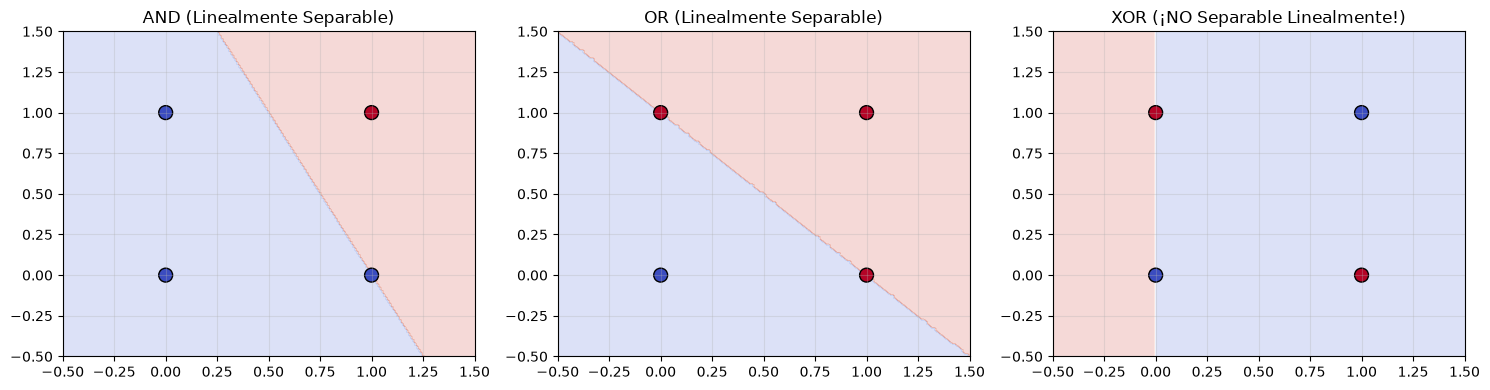

In [5]:
def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)
    
    ax.contourf(xx, yy, preds, alpha=0.2, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, s=100, cmap="coolwarm", edgecolors="k")
    ax.set_title(title)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_decision_boundary(p_and, X_gate, y_and, "AND (Linealmente Separable)", axes[0])
plot_decision_boundary(p_or, X_gate, y_or, "OR (Linealmente Separable)", axes[1])

# Probar en XOR
p_xor = PerceptronNumPy(in_features=2, lr=0.1, max_epochs=20)
p_xor.fit(X_gate, y_xor)
plot_decision_boundary(p_xor, X_gate, y_xor, "XOR (¡NO Separable Linealmente!)", axes[2])

plt.tight_layout()
plt.show()

> ⚠️ **La Limitación Histórica (Minsky & Papert, 1969):** 
> Un perceptrón simple **no puede resolver el problema XOR** ni ninguna función no separable linealmente porque su frontera de decisión es estrictamente un hiperplano (una línea en 2D).

## 4. Probando el Perceptrón en PyTorch con un Dataset Abierto: MNIST (Dígitos 0 vs 1)

Para ver su comportamiento con datos reales, clasificaremos dígitos manuscritos del conjunto **MNIST**, filtrando únicamente los dígitos **0** y **1** (que son altamente separables).

In [6]:
print("Cargando dataset MNIST (filtrando 0 y 1)...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_all, y_all = mnist.data / 255.0, mnist.target.astype(int)

# Filtrar dígitos 0 y 1
mask = (y_all == 0) | (y_all == 1)
X_digits = X_all[mask]
y_digits = y_all[mask]

X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.2, random_state=42)
print(f"Muestras de entrenamiento: {X_train.shape[0]}, Dimensión de entrada: {X_train.shape[1]}")

Cargando dataset MNIST (filtrando 0 y 1)...
Muestras de entrenamiento: 11824, Dimensión de entrada: 784


### Definir el Perceptrón en PyTorch (Linear + Sigmoid/Step)

In [7]:
class PyTorchPerceptron(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)

    def forward(self, x):
        # Usamos Sigmoide para entrenar por Gradiente Descendente (MSE / BCE)
        return torch.sigmoid(self.linear(x))

model = PyTorchPerceptron(in_features=784).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Convertir datos a tensores PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# Entrenamiento
epochs = 20
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 5 == 0:
        preds = (outputs >= 0.5).float()
        acc = (preds == y_train_t).float().mean()
        print(f"Época [{epoch+1}/{epochs}] - Loss: {loss.item():.4f} - Accuracy Train: {acc.item()*100:.2f}%")

# Evaluación
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    test_preds = (test_outputs >= 0.5).float()
    test_acc = (test_preds == y_test_t).float().mean()

print(f"\n✅ Accuracy final en test (MNIST 0 vs 1): {test_acc.item()*100:.2f}%")

Época [5/20] - Loss: 0.2119 - Accuracy Train: 99.47%
Época [10/20] - Loss: 0.1208 - Accuracy Train: 99.56%
Época [15/20] - Loss: 0.0876 - Accuracy Train: 99.62%
Época [20/20] - Loss: 0.0701 - Accuracy Train: 99.62%

✅ Accuracy final en test (MNIST 0 vs 1): 99.90%


## 5. Conclusiones y Preguntas para la Práctica

1. El Perceptrón de Rosenblatt logra casi un **100% de precisión** separando los dígitos `0` y `1` porque sus características de píxeles son linealmente separables.
2. Sin embargo, no puede aprender patrones complejos no lineales ni distinguir 10 clases simultáneamente sin combinar múltiples neuronas en capas ocultas (**MLP - Perceptrón Multicapa**).

👈 **Siguiente paso:** Dirígete a `02_mlp_y_clasificacion/` para construir tu primer MLP y superar la barrera del XOR y MNIST multiclase.